# Lab 2: MCMC (part 1), Metropolis-Hastings

## Advanced Statistical Estimation, Centrale Lille

This lab is about Markov chain Monte Carlo (MCMC) sampling methods. The first exercise implements a Metropolis-Hastings sampler and studies the influence of a few parameters. The second exercise implements a Gibbs sampler for a Bayesian linear regression model (in Lab 3).

**Report by Ugo Roccamatisi.**


In [1]:
# Usual libraries
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as ss

### Exercise - Bayesian logistic regression

Consider the following 1D logistic regression model:
\begin{align}
\beta & \sim \mathcal{N}(0,4) \\
y | x_i, \beta & \sim \text{Bernoulli} \left( \frac{1}{1+\exp(-\beta x)} \right)
\end{align}

(i.e. the intercept is assumed to be 0 for simplicity).

The posterior $p(\beta|\mathcal{D})$ is intractable, so we sample from it with a Metropolis-Hastings (MH) algorithm. The proposal is a normal distribution centered on the current state, with variance $\sigma^2$.


In [2]:
# Generate fake data from the model

np.random.seed(2024)

b = -2.5
N = 50
x = np.random.randn(N)
p = 1/(1+np.exp(-b*x))
y = np.random.rand(N) < p

**Q1.** Write a function implementing this MH algorithm to sample from $p(\beta|\mathcal{D})$, taking as arguments:
* The chain length N;
* The initial state of the chain $\beta^{(0)}$;
* The standard deviation $\sigma$ of the Gaussian proposal;
* A random seed.

Use the pdfs implemented in `scipy.stats`.

In [3]:
from scipy.special import log_expit

def log_posterior(beta):
    # Prior N(0,4): scale=2. log_expit keeps the computation stable at the extremes.
    return ss.norm.logpdf(beta,loc=0,scale=2)+np.sum(y*log_expit(beta*x)+(1-y)*log_expit(-beta*x))

def mh(N,beta0,sigma,seed):
    """Symmetric random-walk MH; N states, including the initial state."""
    if N<2 or sigma<=0:raise ValueError('N>=2 and sigma>0 required')
    rng=np.random.default_rng(seed);chain=np.empty(N);chain[0]=beta0
    old_log=log_posterior(beta0);accepted=0
    for i in range(1,N):
        candidate=chain[i-1]+rng.normal(scale=sigma)
        new_log=log_posterior(candidate)
        # q(candidate|current)=q(current|candidate), so the q terms cancel out.
        if np.log(rng.random())<min(0,new_log-old_log):
            chain[i]=candidate;old_log=new_log;accepted+=1
        else:chain[i]=chain[i-1]
    return chain,accepted/(N-1)

**Q2**. Take $N = 2000$ and $\beta^{(0)} = -1.5$. Show the *trace plots* (i.e. the samples as a function of $n$) of the chain for different values of $\sigma$: $0.01, 0.5, 20$. In each case, plot a histogram of the samples. Comment.

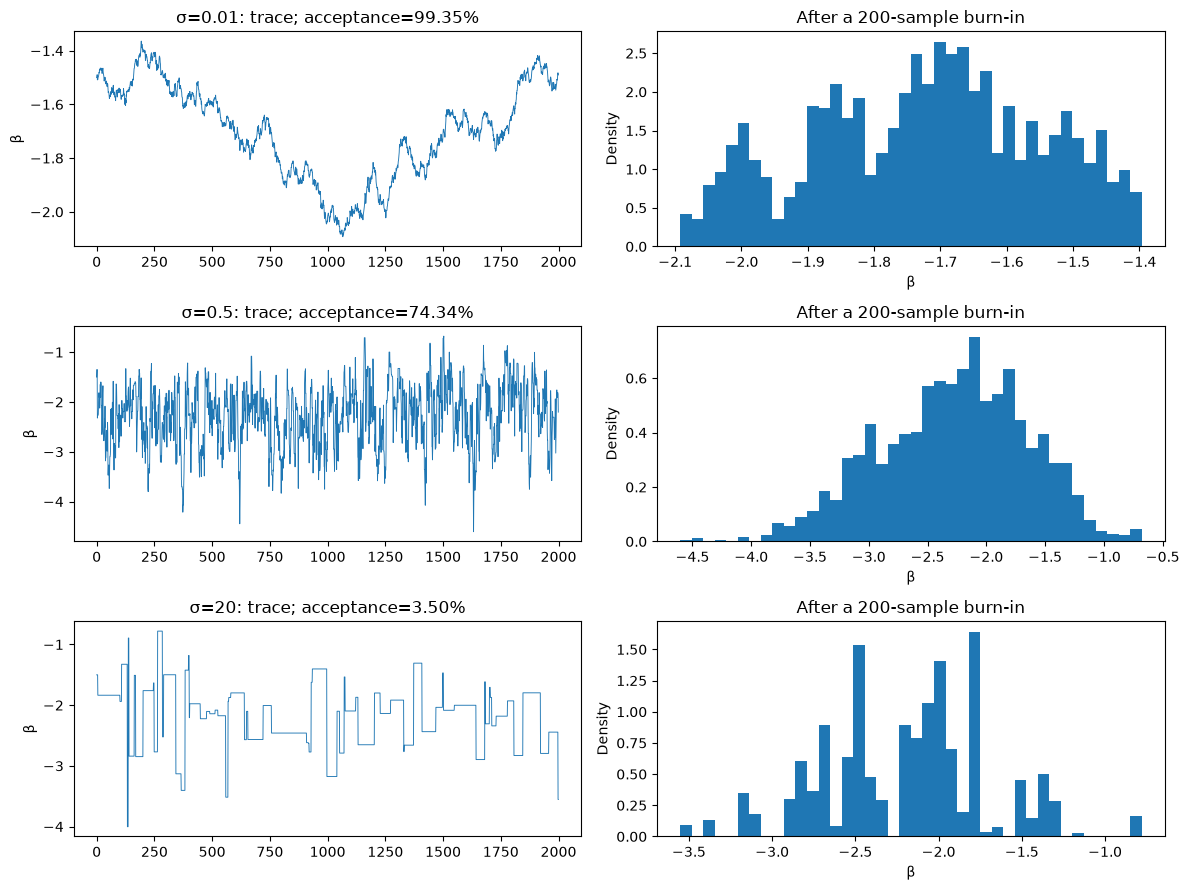

In [4]:
fig,axes=plt.subplots(3,2,figsize=(12,9))
for row,sigma in enumerate([.01,.5,20]):
    chain,accept=mh(2000,-1.5,sigma,seed=42)
    axes[row,0].plot(chain,lw=.65);axes[row,1].hist(chain[200:],bins=40,density=True)
    axes[row,0].set(ylabel='β',title=f'σ={sigma}: trace; acceptance={accept:.2%}')
    axes[row,1].set(xlabel='β',ylabel='Density',title='After a 200-sample burn-in')
fig.tight_layout();plt.show()

**Answer.** A proposal that is too narrow (σ=0.01) is almost always accepted but moves very slowly; one that is too wide (σ=20) is often rejected and the chain repeats its states. σ=0.5 gives a better trade-off here. The histograms of a poorly mixing chain depend strongly on its trajectory.

**Q3.** Take $N = 2000$ and $\sigma = 0.5$. Show the *trace plots* for $\beta^{(0)}$ equal to $-2$ and $20$. In each case, plot a histogram of the samples. Comment.

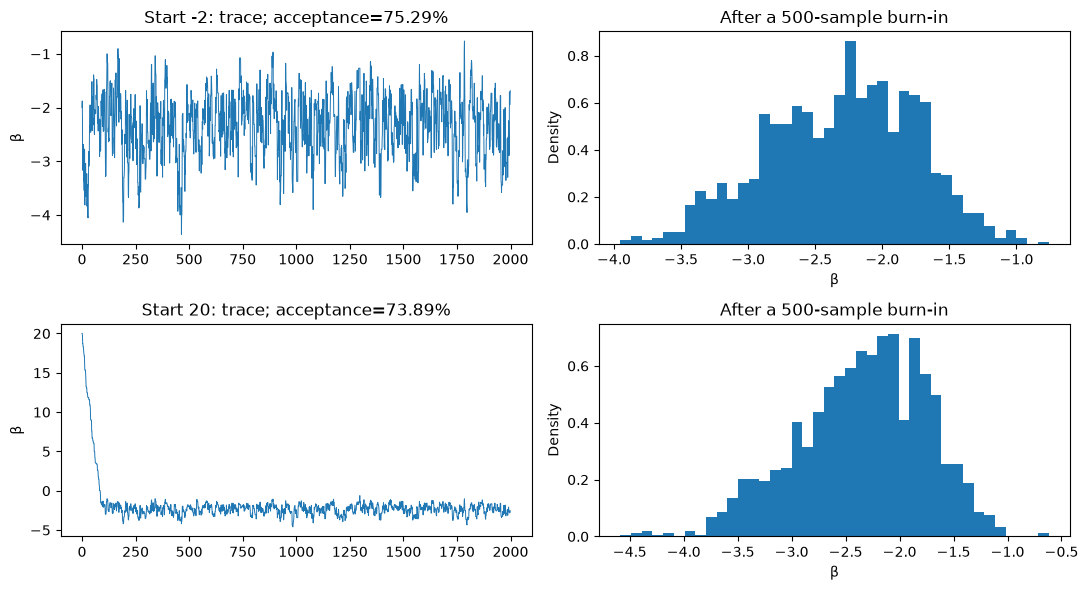

In [5]:
fig,axes=plt.subplots(2,2,figsize=(11,6))
for row,beta0 in enumerate([-2,20]):
    chain,accept=mh(2000,beta0,.5,seed=43)
    axes[row,0].plot(chain,lw=.7);axes[row,1].hist(chain[500:],bins=40,density=True)
    axes[row,0].set(ylabel='β',title=f'Start {beta0}: trace; acceptance={accept:.2%}')
    axes[row,1].set(xlabel='β',ylabel='Density',title='After a 500-sample burn-in')
fig.tight_layout();plt.show()

**Answer.** Starting from β=20 puts the chain far from the high-density region and forces an initial convergence phase; starting from β=−2 is close to the plausible region. The burn-in removes this phase, but does not by itself make the draws independent.

**Q4.** Using samples from a chain with well-chosen $\beta^{(0)}$ and $\sigma$, give the MMSE of $\beta$ and its $95\%$ credible interval.

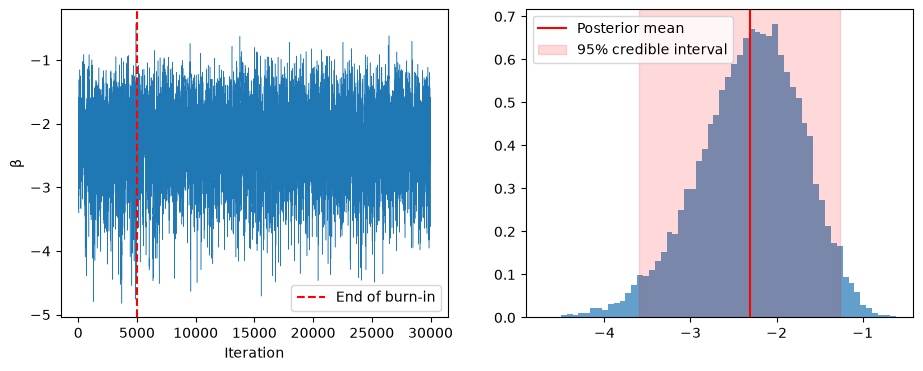

Acceptance=73.95%; MMSE=-2.3089; 95% credible interval=[-3.5963,-1.2599]
Draws from a chain are correlated: this interval is descriptive, not a frequentist CI.


In [6]:
# Longer chain for estimation; the initialization is close to the bulk of the posterior.
posterior_chain,accept=mh(30000,-2,.5,seed=44)
stationary=posterior_chain[5000:]
mmse=stationary.mean();ci=np.quantile(stationary,[.025,.975])
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(posterior_chain,lw=.35);axes[0].axvline(5000,c='r',ls='--',label='End of burn-in');axes[0].legend();axes[0].set(xlabel='Iteration',ylabel='β')
axes[1].hist(stationary,bins=60,density=True,alpha=.7);axes[1].axvline(mmse,c='r',label='Posterior mean');axes[1].axvspan(*ci,color='r',alpha=.15,label='95% credible interval');axes[1].legend();plt.show()
print(f'Acceptance={accept:.2%}; MMSE={mmse:.4f}; 95% credible interval=[{ci[0]:.4f},{ci[1]:.4f}]')
print('Draws from a chain are correlated: this interval is descriptive, not a frequentist CI.')

**Answer.** Under quadratic loss, the MMSE is the empirical posterior mean. The 2.5% and 97.5% quantiles give the central 95% credible interval. Its interpretation is Bayesian: under the model, the parameter lies in this interval with posterior probability 95%.

**Result.** After discarding 5000 draws, the posterior mean is **−2.309** and the central 95% credible interval is **[−3.596, −1.260]**.
